# **Случай регрессии**
Для начала регрессия , есть некий заказчик-девелопер, хочет построить ЖК на точке (X,Y) , для каждой квартиры будут свои параметры, для начала модель предсказывает обьективную стоимость квартир по заданным критериям. (это оставлено скорее для презы)

## Для начала EDA все равно...


In [ ]:
# импорты
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import ParameterSampler, cross_val_score
from scipy.stats import randint, uniform, loguniform
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import time
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, LabelEncoder
from sklearn.model_selection import cross_val_predict, train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings; warnings.filterwarnings('ignore')

In [ ]:
flats = pd.read_csv('cian_parsed.csv')
display(flats.head(1))
flats.isna().sum()

,url,title,price,address,area,floor,year,metro_name,metro_time,house_type,_error,lat,lon,schools_count_800m,clinics_count_800m,kindergartens_count_800m
0,https://www.cian.ru/sale/flat/323603252/,"Продается 3-комн. квартира, 439 м²",1 528 010 000 ₽,"Москва, ЦАО, р-н Хамовники, 3-й Обыденский пер...",439 м²,1 из 6,NaN,Кропоткинская,5 мин.,Монолитный,NaN,55.742835,37.604031,8,10,3


url                             0
title                        2924
price                        5461
address                      5459
area                         5529
floor                        5532
year                        13093
metro_name                   5547
metro_time                   5547
house_type                  10104
_error                      24123
lat                             0
lon                             0
schools_count_800m              0
clinics_count_800m              0
kindergartens_count_800m        0
dtype: int64

In [ ]:
flats = flats.rename(columns={'schools_count_800m':'sch_n', # переименуем некоторые признаки, а то таблицу не видно
'clinics_count_800m':'cli_n','kindergartens_count_800m':'kga_n'})

general = ['price', 'address', 'area', 'floor', 'metro_name']
flats = flats[~flats[general].isna().all(axis=1)]

flats = flats.drop_duplicates(subset=['url'])
flats = flats.drop(columns=['_error', 'url'])


flats = flats.dropna(subset=['price', 'area', 'floor', 'metro_name', 'metro_time']) # тут мало пропусков остается - дроп

# довольно много пропусков в house_type , просто выкинуть не можем

flats['house_type'] = flats['house_type'].fillna('Unknown')  # заполним Unknown, часто пропуски - это новостройки

# сделаем еще признак, годов тоже много пропущено, поэтому не выкинем
flats['year_known'] = flats['year'].notna().astype(int) # сам признак - был ли год или не было

#часто года и типа дома не было именно у новостроек, поэтому заполняем медианой по типу и году

meds = flats.groupby('house_type')['year'].median() # группируем по тип дома - год
flats['year'] = flats['year'].fillna(flats['house_type'].map(meds)) # каждой строке предоставляем медиану его группы

flats['year'] = flats['year'].fillna(flats['year'].median())   # подстраховка мало ли остались nan

# сколько лет дому
flats['age']  = 2026 - flats['year']
flats = flats.drop(columns=['year'])

In [ ]:
def to_num(x):
    if not isinstance(x, str):
        return np.nan #если не строка - nan
    token = re.sub(r'[^0-9]', '', x) # только НЕцифры заменяем на пустую строку
    if token:
        return float(token) # в итоге только цифра остается
    else:
        return np.nan

def to_area(x):
    if not isinstance(x, str):
        return np.nan
    txt = x.replace(',', '.') # заменяем запятые на точки
    token = re.search(r'([\d.]+)', txt) # любая цифра. + означает найти несколько таких [\d.]
    if token:
        return float(token.group(1))  #search выдает обьект поэтому приходится брать то что нам нужно
    else:
        return np.nan

def to_rooms(x):
    if not isinstance(x, str):
        return np.nan

    if 'многокомн' in x:
        return 6

    if 'студи' in x.lower():
        return 0
    token = re.search(r'(\d+)-комн', x) #цифра-комн - ищем шаблон
    if token:
        return float(token.group(1))
    else:
        return np.nan

flats['price_num'] = flats['price'].apply(to_num)
flats['area_num']= flats['area'].apply(to_area)
flats['rooms' ]= flats['title'].apply(to_rooms)

fl = flats['floor'].str.split('\s*из\s*', expand=True) # цифра-из-цифра -> цифра, expand - делает таблицу

flats['floor_n'] = pd.to_numeric(fl[0])
flats['floors_total'] = pd.to_numeric(fl[1])

flats['metro_min'] = pd.to_numeric(flats['metro_time'].str.split(' ', expand=True)[0],errors='coerce') # нечисло -> nan
flats = flats.dropna(subset=['metro_min'])


flats = flats.dropna(subset=['rooms'])


In [ ]:
flats['ppm2_tys'] = flats['price_num'] / flats['area_num'] /1000   # таргет тыс.р./м^2

flats['floor_ratio'] = flats['floor_n'] / flats['floors_total'] # на каком этаже квартира относительно высоты дома

flats['is_first'] = (flats['floor_n'] == 1).astype(int)
flats['is_last']  = (flats['floor_n']== flats['floors_total']).astype(int)

def to_mid(lat, lon, lat_mid=55.7520, lon_mid=37.6175): # формула гаверсинуса
    p = np.pi/180
    a = 0.5 - np.cos((lat_mid-lat)*p)/2 + np.cos(lat*p)*np.cos(lat_mid*p)*(1-np.cos((lon_mid-lon)*p))/2
    return 2*6371*np.arcsin(np.sqrt(a))

flats['dist_center_km'] = to_mid(flats['lat'], flats['lon'])

flats['rayon'] = flats['address'].str.extract(r'р-н\s+([^,]+)') # р-н-1+пробелов-любой символ, кроме запятой

addresses = flats['address'].reset_index(drop=True)

flats = flats.drop(columns=['title', 'price', 'area', 'floor','metro_time', 'metro_name', 'address', 'price_num'])
flats = flats.reset_index(drop=True)
flats.head()

,house_type,lat,lon,sch_n,cli_n,kga_n,year_known,age,area_num,rooms,floor_n,floors_total,metro_min,ppm2_tys,floor_ratio,is_first,is_last,dist_center_km,rayon
0,Монолитный,55.742835,37.604031,8,10,3,0,7.0,439.0,3.0,1,6,5.0,3480.660592,0.166667,1,0,1.322554,Хамовники
1,Unknown,55.764647,37.580769,4,20,11,1,55.0,47.0,2.0,5,10,7.0,721.276596,0.500000,0,0,2.694286,Пресненский
2,Монолитный,55.795938,37.485537,5,7,10,1,16.0,227.0,5.0,2,27,5.0,405.286344,0.074074,0,0,9.590987,Щукино
3,Unknown,55.753875,37.600625,11,30,6,0,4.0,100.2,2.0,5,8,3.0,3400.000000,0.625000,0,0,1.076367,Арбат
4,Монолитный,55.739415,37.601464,8,7,3,1,20.0,584.0,6.0,5,6,8.0,1942.097260,0.833333,0,0,1.722098,Хамовники


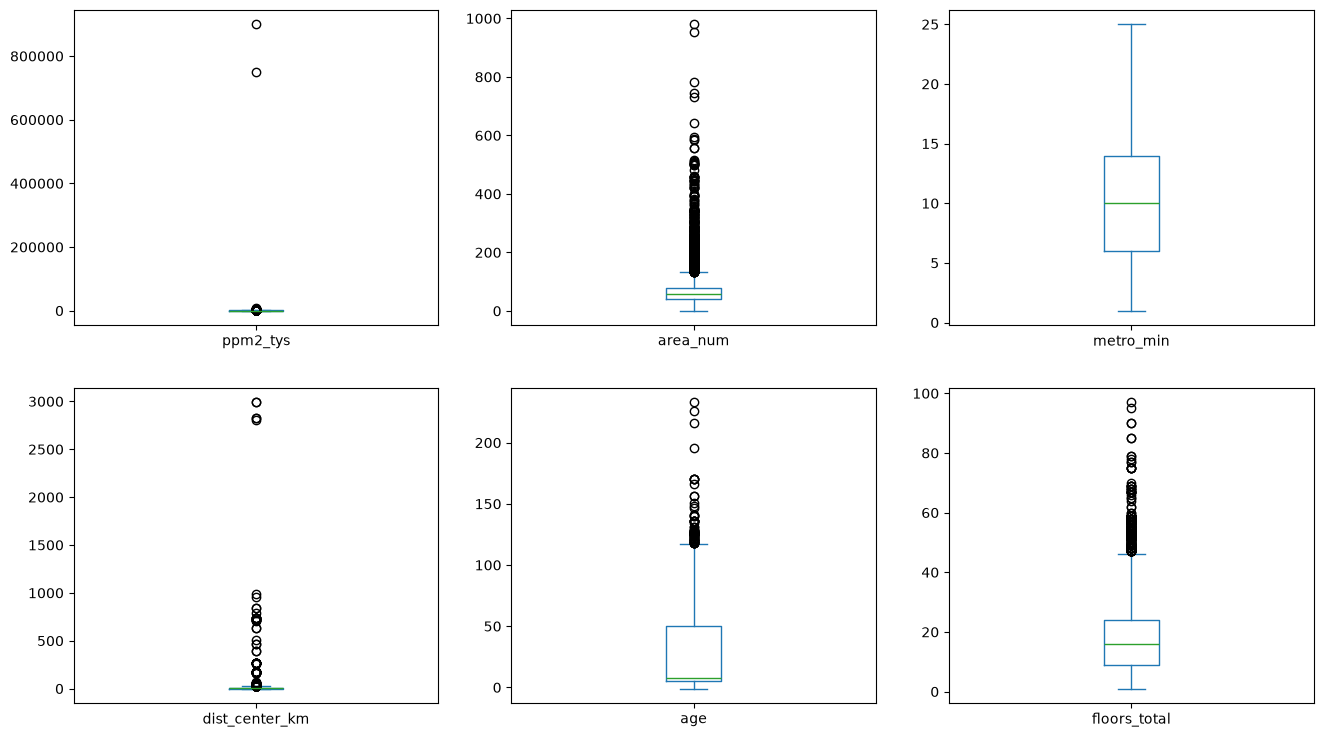

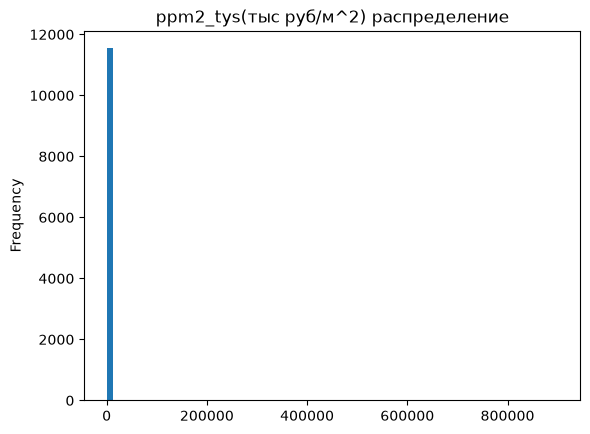

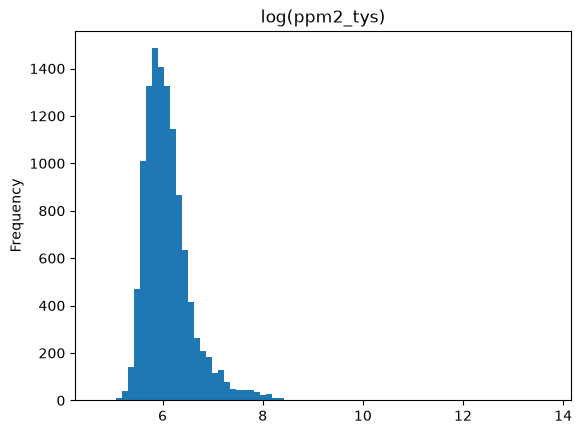

In [ ]:
cols = ['ppm2_tys', 'area_num', 'metro_min', 'dist_center_km', 'age', 'floors_total']

flats[cols].plot(kind='box',subplots=True,layout=(2, 3), figsize=(16, 9))
plt.show()

flats['ppm2_tys'].plot(kind='hist', bins=75,title='ppm2_tys(тыс руб/м^2) распределение')
plt.show()

np.log(flats['ppm2_tys']).plot(kind='hist', bins=75, title='log(ppm2_tys)')
plt.show()

In [ ]:
flats = flats[(flats['ppm2_tys'] <= 3000) &(flats['metro_min'] <= 60) &(flats['dist_center_km'] <= 60)].copy()

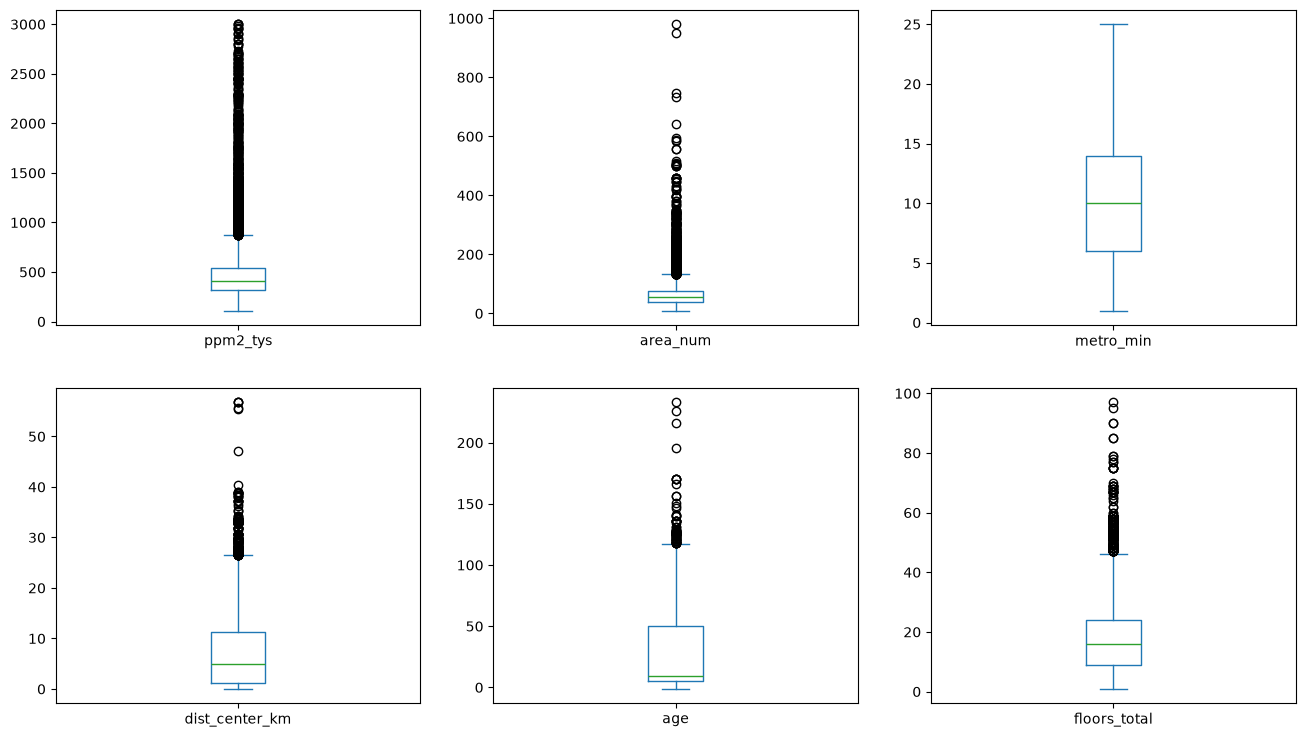

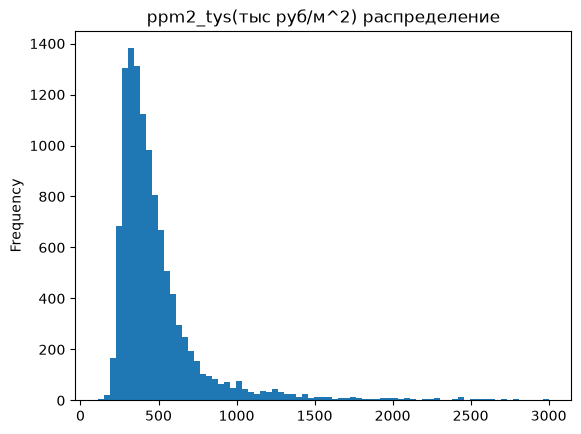

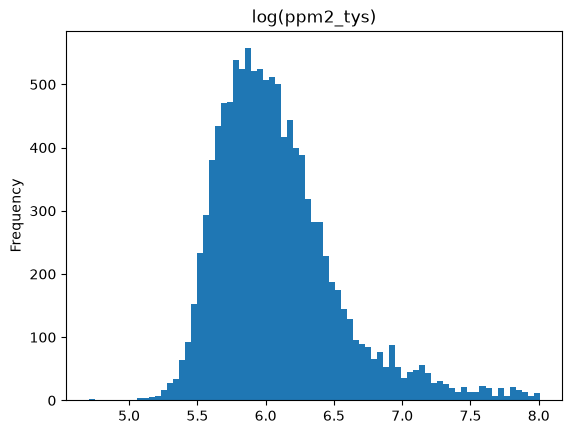

In [ ]:
flats[cols].plot(kind='box',subplots=True,layout=(2, 3), figsize=(16, 9))
plt.show()

flats['ppm2_tys'].plot(kind='hist', bins=75,title='ppm2_tys(тыс руб/м^2) распределение')
plt.show()

np.log(flats['ppm2_tys']).plot(kind='hist', bins=75, title='log(ppm2_tys)')
plt.show()

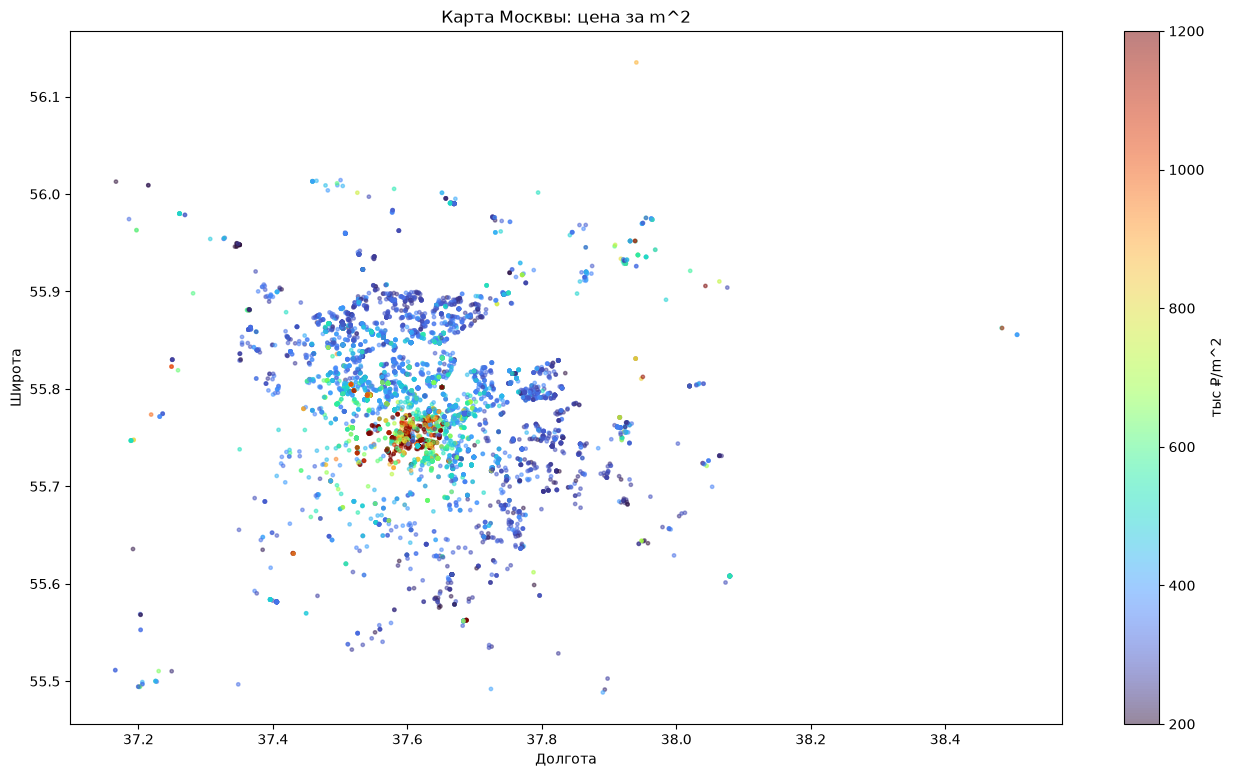

In [ ]:
plt.figure(figsize=(16, 9))
plt.scatter(flats['lon'], flats['lat'], c=flats['ppm2_tys'],cmap='turbo', s=6, alpha=0.5, vmin=200, vmax=1200)
plt.colorbar(label='тыс ₽/m^2')
plt.title('Карта Москвы: цена за m^2')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.show()

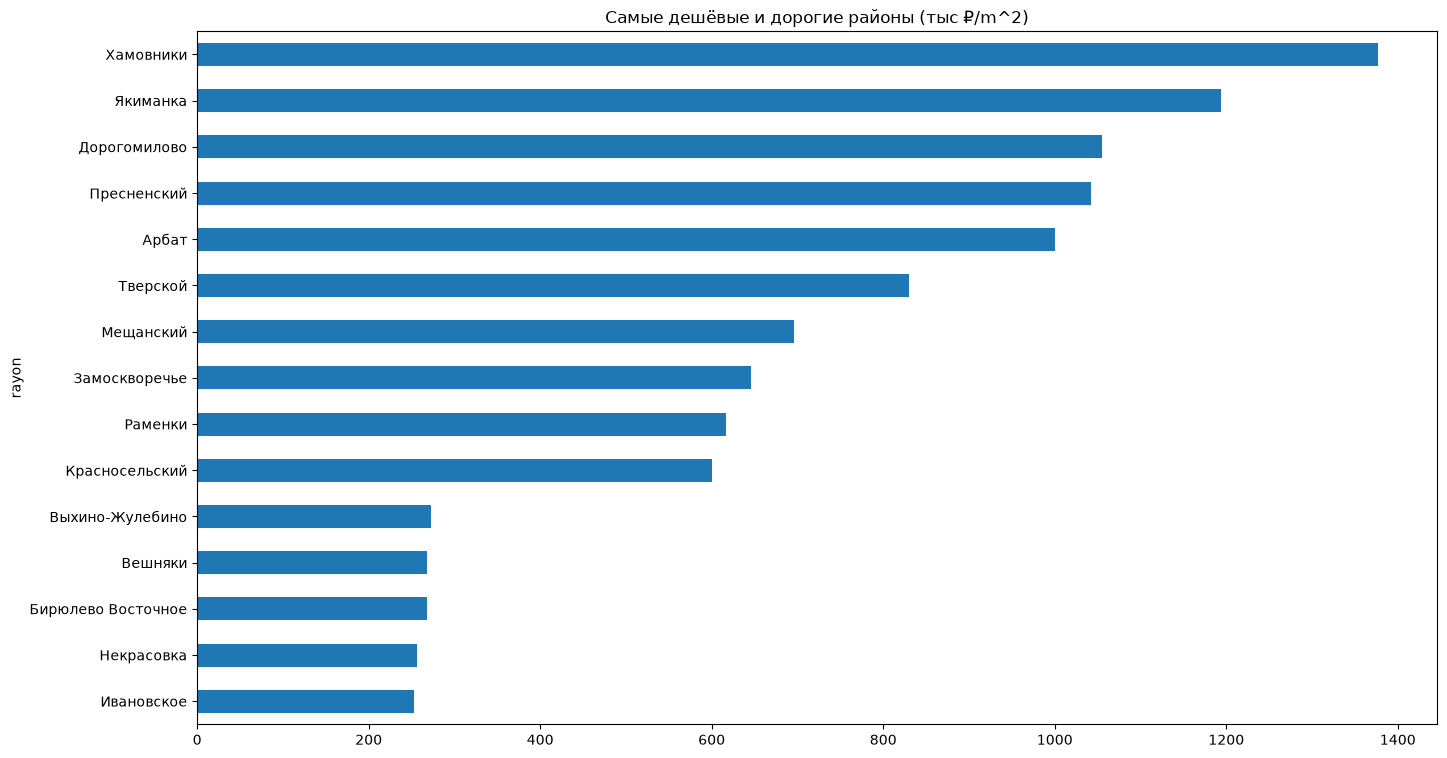

In [ ]:
med = flats.groupby('rayon')['ppm2_tys'].median()

n = flats['rayon'].value_counts()

med = med[n >= 30].sort_values()

top = pd.concat([med.head(5),med.tail(10)])

top.plot(kind='barh', figsize=(16, 9),
title='Самые дешёвые и дорогие районы (тыс ₽/m^2)')

plt.show()

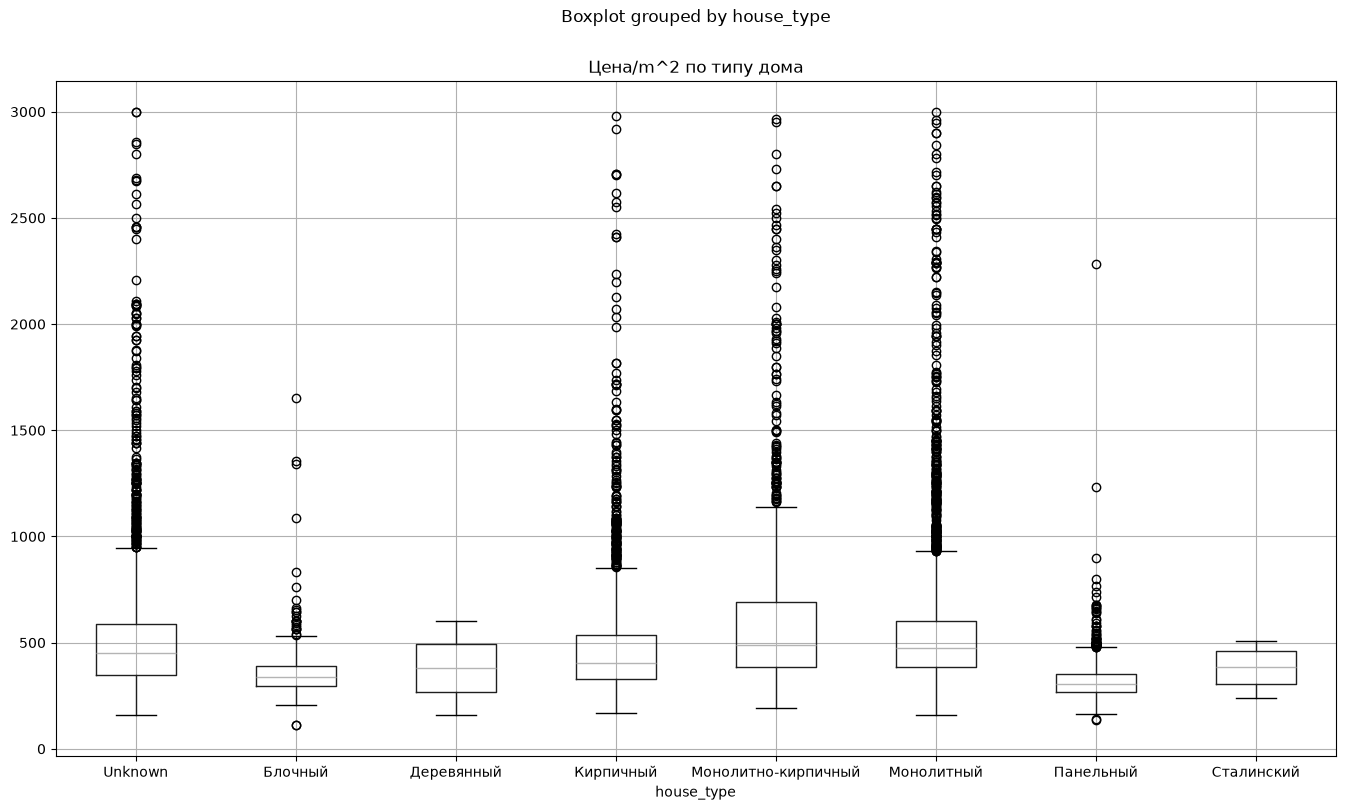

In [ ]:
flats.boxplot(column='ppm2_tys', by='house_type', figsize=(16, 9))
plt.title('Цена/m^2 по типу дома')
plt.show()


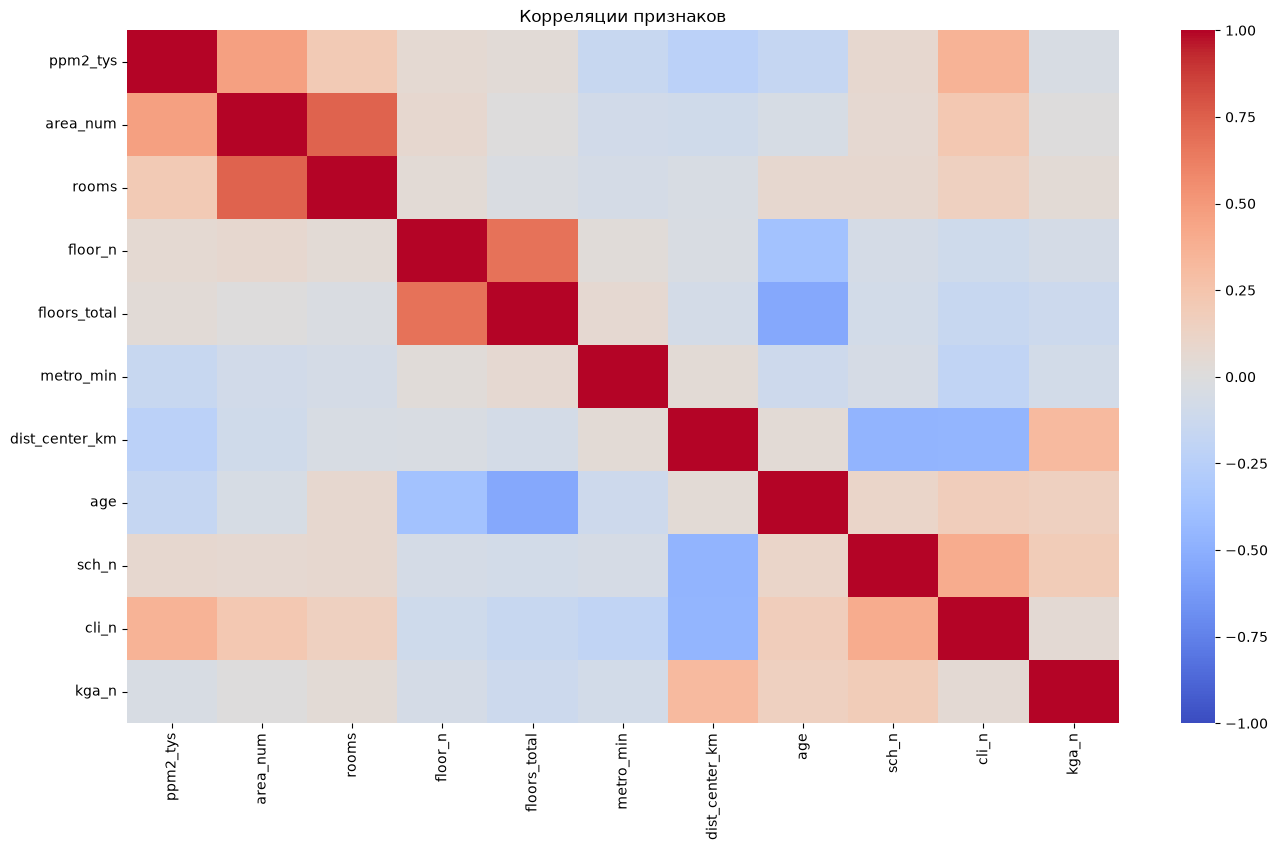

In [ ]:
nums = ['ppm2_tys', 'area_num', 'rooms', 'floor_n', 'floors_total', 'metro_min',
       'dist_center_km', 'age', 'sch_n', 'cli_n', 'kga_n']

plt.figure(figsize=(16, 9))
sns.heatmap(flats[nums].corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляции признаков')
plt.show()

In [ ]:
flats

,house_type,lat,lon,sch_n,cli_n,kga_n,year_known,age,area_num,rooms,floor_n,floors_total,metro_min,ppm2_tys,floor_ratio,is_first,is_last,dist_center_km,rayon
1,Unknown,55.764647,37.580769,4,20,11,1,55.0,47.0,2.0,5,10,7.0,721.276596,0.500000,0,0,2.694286,Пресненский
2,Монолитный,55.795938,37.485537,5,7,10,1,16.0,227.0,5.0,2,27,5.0,405.286344,0.074074,0,0,9.590987,Щукино
4,Монолитный,55.739415,37.601464,8,7,3,1,20.0,584.0,6.0,5,6,8.0,1942.097260,0.833333,0,0,1.722098,Хамовники
5,Unknown,55.749415,37.524221,1,0,7,1,3.0,72.0,3.0,5,41,14.0,652.777778,0.121951,0,0,5.844433,Хорошево-Мневники
6,Unknown,55.774539,37.684998,7,8,10,1,49.0,53.0,2.0,2,12,19.0,338.679245,0.166667,0,0,4.910430,Северное Тушино
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11538,Unknown,55.690888,37.689388,3,3,1,1,2.0,41.2,2.0,5,26,15.0,449.029126,0.192308,0,0,8.151378,Нагатино-Садовники
11539,Unknown,55.937461,37.942964,0,1,2,1,3.0,64.0,2.0,18,20,12.0,561.718750,0.900000,0,0,28.950205,Даниловский
11540,Панельный,55.640541,37.628130,0,1,1,1,38.0,75.0,3.0,15,17,20.0,284.000000,0.882353,0,0,12.411570,Москворечье-Сабурово
11541,Unknown,55.741469,37.615561,7,7,0,1,1.0,73.0,2.0,11,30,7.0,520.547945,0.366667,0,0,1.177265,Даниловский


## ML MODELS ЗАДАЧА 1 - РЕГРЕССИЯ

### preprocessing

In [ ]:
flats['log_ppm2'] = np.log(flats['ppm2_tys'])
flats['rayon'] = flats['rayon'].fillna('Unknown')

num_features = ['area_num', 'rooms','floor_n', 'floors_total','floor_ratio',
'is_first', 'is_last','metro_min', 'dist_center_km','age','year_known', 'sch_n',  'cli_n', 'kga_n', 'lat','lon']

ohe_house = ['house_type']
dist_feature = ['rayon']

X = flats.drop(columns=['log_ppm2', 'ppm2_tys'])
y = flats['log_ppm2']

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.2)

preprocessing = ColumnTransformer([('num', StandardScaler(),num_features),
('ohe', OneHotEncoder(handle_unknown='ignore'),ohe_house),
('te',  TargetEncoder(),dist_feature),])


In [ ]:
models = {
    'Decision Tree':DecisionTreeRegressor(random_state=0),'XGBoost': XGBRegressor(n_jobs=-1, random_state=0),
    'Random Forest': RandomForestRegressor(n_jobs=-1, random_state=0),'Ridge_reg':Ridge(),
    'KNN': KNeighborsRegressor(),'SVR': SVR(),
    'Gradient Boosting':GradientBoostingRegressor(random_state=0),'MLP': MLPRegressor(max_iter=300, early_stopping=True, random_state=0),
}

results = []
for name, m in models.items():

    pipe = Pipeline([('prep', preprocessing), ('model', m) ])

    pipe.fit(X_train,y_train)

    pred_log = pipe.predict(X_test)

    pred, norm_values = np.exp(pred_log),np.exp(y_test)

    results.append({'MODEL':name,'R^2': r2_score(y_test, pred_log),
    'MAE': mean_absolute_error(norm_values, pred),
    'MAPE': mean_absolute_percentage_error(norm_values,pred)})

res = pd.DataFrame(results).sort_values('R^2', ascending=False)
res


,MODEL,R^2,MAE,MAPE
2,Random Forest,0.809588,73.164018,0.134726
1,XGBoost,0.796504,76.970768,0.140794
6,Gradient Boosting,0.745774,90.300684,0.164267
5,SVR,0.730987,93.794318,0.167841
7,MLP,0.709481,96.259812,0.177706
3,Ridge_reg,0.677990,104.267294,0.190691
4,KNN,0.623771,104.437056,0.192445
0,Decision Tree,0.582770,105.269713,0.196480


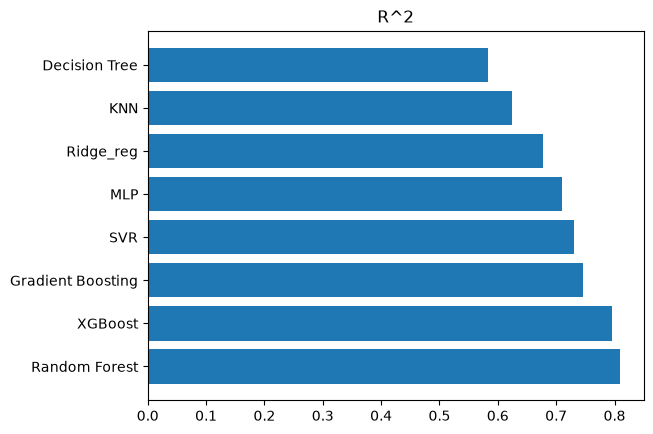

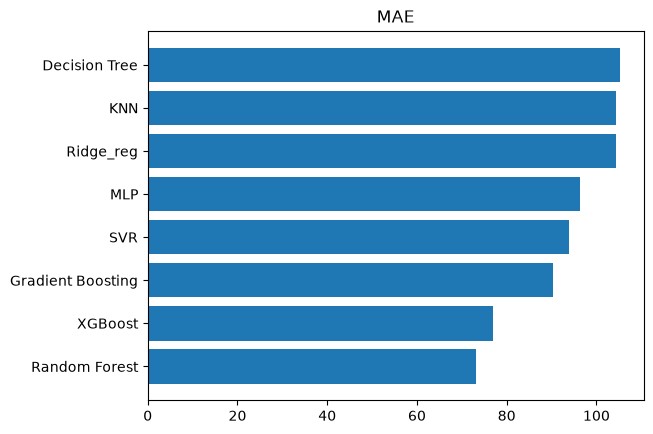

In [ ]:
plt.barh(res['MODEL'], res['R^2'])
plt.title('R^2')
plt.show()

plt.barh(res['MODEL'], res['MAE'])
plt.title('MAE')
plt.show()

In [ ]:
rng = np.random.RandomState(0)

X_val_tr, X_val, y_val_tr, y_val = train_test_split(X_train, y_train, random_state=rng , test_size=0.2)

param_grid = {
    'n_estimators': randint(200, 800),
    'max_depth': randint(7, 30),
    'min_samples_leaf': randint(1, 15),
    'min_samples_split': randint(2, 21),
    'max_features':uniform(0.3, 0.7),
}
param_list = list(ParameterSampler(param_grid, n_iter=40, random_state=rng))


preds = [Pipeline([('prep', preprocessing),('model', RandomForestRegressor(**p, n_jobs=-1, random_state=rng))])
.fit(X_val_tr, y_val_tr).predict(X_val) for p in param_list]

mapes = [mean_absolute_percentage_error(np.exp(y_val), np.exp(pred)) for pred in preds]

idx = np.argmin(mapes)

best_params_rf = param_list[idx]

print('params', best_params_rf)

print(f'MAPE: {mapes[idx]* 100}%')

params {'max_depth': 29, 'max_features': np.float64(0.4389194465130589), 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 609}
MAPE: 14.082246968904052%


In [ ]:
param_grid = {
    'gamma': uniform(0, 0.5),
    'learning_rate': uniform(0.05, 0.25),
    #'max_delta_step': randint(1,10), - слишком ограничивает шаг нашего дерева, поэтому кик
    'max_depth': randint(3,10),
    'min_child_weight': randint(1,6),
    'n_estimators': randint(50,401),
    'subsample': uniform(0.6, 0.4)
}

param_list = list(ParameterSampler(param_grid, n_iter=50, random_state=rng))

preds = [Pipeline([('prep', preprocessing),('model', XGBRegressor(**p, random_state=rng))])
.fit(X_val_tr, y_val_tr).predict(X_val) for p in param_list]

mapes = [mean_absolute_percentage_error(np.exp(y_val), np.exp(pred)) for pred in preds]

idx = np.argmin(mapes)

best_params = param_list[idx]

print('params', best_params)

print(f'MAPE: {mapes[idx]* 100}%')

params {'gamma': np.float64(0.005301112415976805), 'learning_rate': np.float64(0.1498566223345416), 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 353, 'subsample': np.float64(0.8330713479711106)}
MAPE: 14.171625874092802%


In [ ]:
# тест и потом функция останется
best_rf = Pipeline([('prep', preprocessing),
('model', RandomForestRegressor(**best_params_rf, n_jobs=-1, random_state=0 ))]).fit(X_train, y_train)

pred, norm_for_rf = np.exp(best_rf.predict(X_test)),np.exp(y_test)

print('TEST R^2:', r2_score(y_test, best_rf.predict(X_test)),
'TEST MAPE:', mean_absolute_percentage_error(norm_for_rf, pred) * 100)

TEST R^2: 0.8152477904989369 TEST MAPE: 13.500988503237096


In [ ]:
nn = NearestNeighbors(n_neighbors=5).fit(flats[['lat', 'lon']].values)


def location_features(lat, lon):
    i, idx = nn.kneighbors([[lat, lon]])
    nbf = flats.iloc[idx[0]]
    return dict(metro_min= nbf['metro_min'].median(),sch_n=nbf['sch_n'].median(),
        cli_n=nbf['cli_n'].median(), kga_n=nbf['kga_n'].median(),
        rayon=nbf['rayon'].mode()[0], dist_center_km=to_mid(lat, lon))

def predictor_for_proj(lat, lon, area, rooms, floor_n, floors_total, house_type='Монолитный', age=0):

    loc = location_features(lat, lon)

    row =pd.DataFrame([{'area_num': area, 'rooms': rooms, 'floor_n': floor_n,
        'floors_total': floors_total,'floor_ratio': floor_n/floors_total, 'is_first': int(floor_n==1),
        'is_last': int(floor_n==floors_total),'metro_min': loc['metro_min'], 'dist_center_km': loc['dist_center_km'],
        'age': age, 'year_known': 1,'sch_n': loc['sch_n'],
        'cli_n': loc['cli_n'], 'kga_n': loc['kga_n'],'lat': lat,
        'lon': lon, 'house_type': house_type, 'rayon': loc['rayon']}])

    return np.exp(best_rf.predict(row))[0]


def revenue_ppm2(lat, lon, n_flats=200, avg_area=55, floors_total=25, house_type='Монолитный'):

    ppm2 = predictor_for_proj(lat, lon, area=avg_area, rooms=2, floor_n=floors_total//2,
    floors_total=floors_total, house_type=house_type, age=0)

    total_area = n_flats * avg_area

    revenue = ppm2 * 1000 * total_area

    print(f'Прогноз цены: {ppm2} тыс. руб./м^2')
    print(f'Площадь ЖК: {total_area} м,2 ({n_flats} квартир {avg_area} м^2)')
    print(f'Потенциальная выручка: {revenue/1e9} млрд. руб.')

    return ppm2, revenue


revenue_ppm2(55.736, 37.585, n_flats=200, avg_area=55)
revenue_ppm2(55.687, 37.825, n_flats=200, avg_area=55)


Прогноз цены: 941.1847555683833 тыс. руб./м^2
Площадь ЖК: 11000 м,2 (200 квартир 55 м^2)
Потенциальная выручка: 10.353032311252216 млрд. руб.
Прогноз цены: 297.99831417551076 тыс. руб./м^2
Площадь ЖК: 11000 м,2 (200 квартир 55 м^2)
Потенциальная выручка: 3.2779814559306186 млрд. руб.


(np.float64(297.99831417551076), np.float64(3277981455.930619))

In [ ]:
scenarios = [('Центр премиум',55.736, 37.585, 120,  75, 12, 'Монолитный'),
('Окраина масс', 55.687, 37.825, 400,  45, 30, 'Панельный'),
('Комфорт САО',55.805, 37.515, 250,  55, 22, 'Монолитный'),
('Элитка ЦАО', 55.735, 37.630,  60, 110,  9, 'Кирпичный')]

rows = []
for name, lat, lon, n, area, fl_n, ht in scenarios:

    ppm2 = predictor_for_proj(lat, lon, area=area, rooms=2, floor_n=fl_n//2,floors_total=fl_n, house_type=ht, age=0)

    rows.append({'Сценарий': name, 'Цена тыс руь / м^2 ': round(ppm2),'Площадь м^2': n*area, 'Выручка млрд. руб.': ppm2*1000*n*area/1e9})

pd.DataFrame(rows)

,Сценарий,Цена тыс руь / м^2,Площадь м^2,Выручка млрд. руб.
0,Центр премиум,1092,9000,9.827460
1,Окраина масс,296,18000,5.320682
2,Комфорт САО,679,13750,9.332247
3,Элитка ЦАО,1050,6600,6.929822


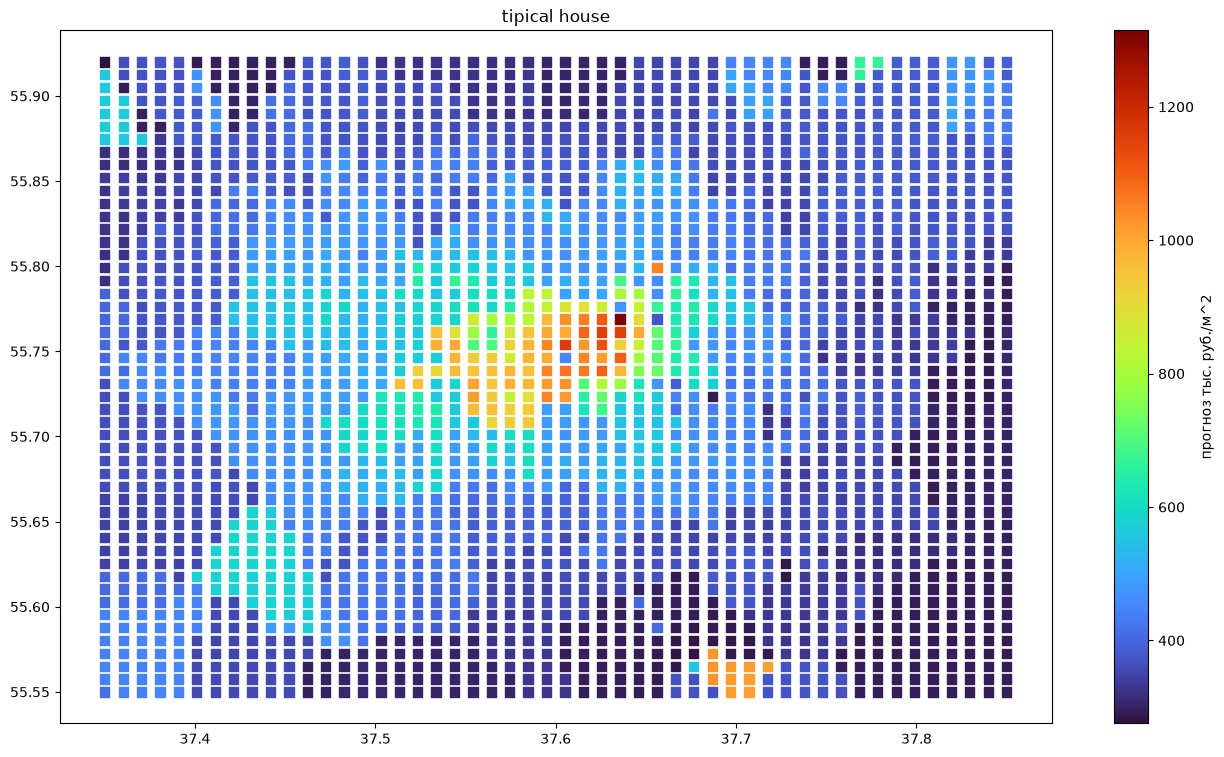

In [ ]:
lats = np.linspace(55.55, 55.92, 50)
lons = np.linspace(37.35, 37.85, 50)
grid = [(la, lo) for la in lats for lo in lons]
gdf = pd.DataFrame(grid, columns=['lat', 'lon'])
gdf['ppm2'] = [predictor_for_proj(la, lo, area=55, rooms=2, floor_n=12, floors_total=25) for la, lo in grid]

plt.figure(figsize=(16, 9))
plt.scatter(gdf['lon'], gdf['lat'], c=gdf['ppm2'], cmap='turbo', s=45, marker='s')
plt.colorbar(label='прогноз тыс. руб./м^2')
plt.title('tipical house')
plt.show()

# Классификация: восстановление типа дома (`house_type`)

Бизнес-задача: У 42% объявлений ЦИАН не заполнен тип дома (`house_type`). Это важный признак для оценки цены, и наша регрессия сейчас теряет его (`fillna('Unknown')`). Здесь мы обучаем классификатор, который **восстанавливает тип дома** по локации, этажности, возрасту и инфраструктуре, и сохраняет результат в `flats_filled.csv` - его подхватывает Муха в регрессии.



In [ ]:
# импорты

import warnings, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (f1_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline   # pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

## быстрый EDA

In [ ]:
# загрузим и почистим данные еще раз

flats = pd.read_csv('cian_parsed.csv').drop(columns=['_error']) # удаляем error, колонка появилась еще когда парсили циан
core = ['price', 'address', 'area', 'floor', 'metro_name']
flats = flats[~flats[core].isna().all(axis=1)] # не берем строки, в которых пустое значение в 5 важных колонках
flats = flats.drop_duplicates(subset=['url'])
flats = flats.dropna(subset=['price', 'area'])
flats = flats.dropna(subset=['floor', 'metro_name', 'metro_time'])

# итоги чистки
print('строк после чистки:', len(flats))
print('пропусков house_type:', flats['house_type'].isna().sum())

строк после чистки: 11835
пропусков house_type: 3026


In [ ]:
# feature-engineering

# преобразуем данные в числовые корректно
def to_area(x):
    if not isinstance(x, str): return np.nan
    m = re.search(r'([\d.]+)', x.replace(',', '.'))
    return float(m.group(1)) if m else np.nan # ищем первый кусок из цифр и точек, затем превращаем в число

def to_rooms(t):
    if not isinstance(t, str): return np.nan
    if 'многокомн' in t: return 6 # многокомнатные = 7
    if 'студи' in t.lower(): return 0
    m = re.search(r'(\d+)-комн', t)
    return float(m.group(1)) if m else np.nan # формат записи "x - комн", вынимаем x

flats['area_num'] = flats['area'].apply(to_area)
flats['rooms']    = flats['title'].apply(to_rooms)
fl = flats['floor'].str.extract(r'(\d+)\s*из\s*(\d+)') # "x из y" формат, вынимаем x и y
flats['floor_n'] = pd.to_numeric(fl[0])
flats['floors_total'] = pd.to_numeric(fl[1])
flats['metro_min'] = pd.to_numeric(flats['metro_time'].str.extract(r'(\d+)')[0])
flats = flats.dropna(subset=['rooms'])

flats['floor_ratio'] = flats['floor_n'] / flats['floors_total']  # чтобы понимать насколько высок этаж из всех используем floor_ratio
flats['is_first'] = (flats['floor_n'] == 1).astype(int) # для первых этажей
flats['is_last']  = (flats['floor_n'] == flats['floors_total']).astype(int) # для последних этажей

# функция гаверсинуса. Мы считаем расстояние от 2 точек до центра МСК https://stackoverflow.com/questions/4913349/haversine-formula-in-python-bearing-and-distance-between-two-gps-points
def haversine(lat, lon, lat0=55.7520, lon0=37.6175):
    p = np.pi/180 # перевод градусов в радианы
    a = 0.5 - np.cos((lat0-lat)*p)/2 + np.cos(lat*p)*np.cos(lat0*p)*(1-np.cos((lon0-lon)*p))/2
    return 2*6371*np.arcsin(np.sqrt(a)) # тут 6371 - это радиус земли в км
flats['dist_center_km'] = haversine(flats['lat'], flats['lon'])


flats['year_known'] = flats['year'].notna().astype(int)  # флаг знаем ли мы год
flats['year'] = flats['year'].fillna(flats['year'].median())  # заполняем медианой пустые значения
flats['age']  = 2026 - flats['year']  # находим age здания

flats['rayon'] = flats['address'].str.extract(r'р-н\s+([^,]+)').fillna('Unknown')  # формируем строку "р-н (все до следующей запятой)"

flats = flats.rename(columns={'schools_count_800m':'sch_n',
                              'clinics_count_800m':'cli_n',
                              'kindergartens_count_800m':'kga_n'})


flats.loc[flats['metro_min'] > 60, 'metro_min'] = np.nan   # тут парсер вытащил "год сдачи" вместо минут до метро кое-где. Чистим колонку
flats['metro_min'] = flats['metro_min'].fillna(flats['metro_min'].median())
flats = flats[flats['dist_center_km'] <= 60].copy()
print(flats.shape)

(11517, 27)


Смотрим на пропуски

In [ ]:
na = flats['house_type'].isna()
print('year пуст, когда тип ЕСТЬ :', round(flats.loc[~na,'year_known'].eq(0).mean()*100,1), '%')
print('year пуст, когда тип ПУСТ :', round(flats.loc[ na,'year_known'].eq(0).mean()*100,1), '%')
print('медиана этажности: тип есть =', flats.loc[~na,'floors_total'].median(),
      ', тип пуст =', flats.loc[na,'floors_total'].median())

year пуст, когда тип ЕСТЬ : 37.6 %
year пуст, когда тип ПУСТ : 49.0 %
медиана этажности: тип есть = 14.0 , тип пуст = 21.0


## Работа с моделью

In [ ]:
# тагрет

flats['house_type'] = flats['house_type'].replace({'Сталинский':'Кирпичный'})
flats = flats[flats['house_type'] != 'Деревянный']
print(flats['house_type'].value_counts(dropna=False))

house_type
Монолитный             3288
NaN                    2970
Панельный              2136
Кирпичный              1812
Монолитно-кирпичный     754
Блочный                 555
Name: count, dtype: int64


In [ ]:
num_features = ['area_num','floor_n','floors_total','floor_ratio','is_first','is_last',
                'metro_min','dist_center_km','age','year_known','sch_n','cli_n','kga_n','lat','lon']  # числовые признаки
ohe_features = ['rooms'] # one hot юзаем
te_features  = ['rayon'] # target encoding юзаем т.к слишком много значений
feat = num_features + ohe_features + te_features

lab   = flats[flats['house_type'].notna()].copy()   # размеченные - учим на них
unlab = flats[flats['house_type'].isna()].copy()    # пустые - их заполняем
print('размечено:', len(lab), ', заполнить:', len(unlab))

le = LabelEncoder()
y  = le.fit_transform(lab['house_type'])
X  = lab[feat].copy()
X['rooms'] = X['rooms'].astype(str)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

prep = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('ohe', OneHotEncoder(handle_unknown='ignore'), ohe_features),
    ('te',  TargetEncoder(), te_features),
]) # удобный преобразователь для моделей далее

размечено: 8545 , заполнить: 2970


In [ ]:
models = {
    'LogReg': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'SVM': SVC(C=5, gamma='scale'),
    'Decision Tree': DecisionTreeClassifier(max_depth=14, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
                                     subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                                     eval_metric='mlogloss', random_state=42),
    'MLP (нейросеть)': MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300, random_state=42),
}

rows = []
for name, mdl in models.items():
    pipe = ImbPipeline([('prep', prep), ('smote', SMOTE(random_state=42)), ('model', mdl)])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    rows.append({'модель': name,
                 'macro_F1': round(f1_score(y_te, pred, average='macro'), 3), # макро усредняет с равным весом
                 'balanced_acc': round(balanced_accuracy_score(y_te, pred), 3)})

res = pd.DataFrame(rows).sort_values('macro_F1', ascending=False).reset_index(drop=True)
res

,модель,macro_F1,balanced_acc
0,XGBoost,0.740,0.738
1,Random Forest,0.734,0.729
2,Decision Tree,0.632,0.658
3,SVM,0.626,0.647
4,MLP (нейросеть),0.624,0.620
5,LogReg,0.558,0.607
6,KNN,0.476,0.536


In [ ]:
# тут такая проблема: классов сильно неравное кол-во (монолита дофига, блочного мало).
# проверяем 3 способа побороть дисбаланс и смотрим, у кого macro_F1 выше:
# без баланса — обычный лес, для сравнения. class_weight — лес штрафуем за ошибки
# на редких классах сильнее. SMOTE — генерим синтетические примеры редких классов,
# чтоб выровнять. по цифрам лучший SMOTE, его и оставляем в финале.

variants = {
    'без баланса': [('prep', prep), ('model', RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42))],
    'class_weight': [('prep', prep), ('model', RandomForestClassifier(n_estimators=300, n_jobs=-1, class_weight='balanced', random_state=42))],
    'SMOTE': [('prep', prep), ('smote', SMOTE(random_state=42)), ('model', RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42))],
}
for tag, steps in variants.items():
    p = ImbPipeline(steps)
    p.fit(X_tr, y_tr)
    pr = p.predict(X_te)
    print(f'{tag:14s} macro_F1={f1_score(y_te, pr, average="macro"):.3f}  '
          f'balanced_acc={balanced_accuracy_score(y_te, pr):.3f}')

без баланса    macro_F1=0.714  balanced_acc=0.680
class_weight   macro_F1=0.742  balanced_acc=0.736
SMOTE          macro_F1=0.735  balanced_acc=0.729


## Тюнинг и результаты лучшей модели (XGBoost)

In [ ]:
from scipy.stats import randint, uniform, loguniform
param_dist = {
    'model__n_estimators': randint(300, 900),
    'model__learning_rate': loguniform(0.01, 0.2),   # learning_rate на логарифмической шкале. Чтобы плотнее пробовать значения
    'model__max_depth': randint(3, 9),
    'model__subsample': uniform(0.7, 0.3),   # равномерное распределение
    'model__colsample_bytree': uniform(0.7, 0.3),
}
pipe_xgb = ImbPipeline([('prep', prep), ('smote', SMOTE(random_state=42)),
                        ('model', XGBClassifier(n_jobs=-1, eval_metric='mlogloss', random_state=42))])  # пайплайн
search = RandomizedSearchCV(pipe_xgb, param_dist, n_iter=15, cv=3,
                            scoring='f1_macro', n_jobs=-1, random_state=42)   # random search
search.fit(X_tr, y_tr)
print('лучший CV macro_F1:', round(search.best_score_, 3))
print('на тесте macro_F1 :', round(f1_score(y_te, search.predict(X_te), average='macro'), 3))
search.best_params_

лучший CV macro_F1: 0.739
на тесте macro_F1 : 0.752


{'model__colsample_bytree': np.float64(0.8560204063533432),
 'model__learning_rate': np.float64(0.05143828405076928),
 'model__max_depth': 8,
 'model__n_estimators': 776,
 'model__subsample': np.float64(0.9908753883293675)}

                     precision    recall  f1-score   support

            Блочный       0.74      0.60      0.66       111
          Кирпичный       0.80      0.84      0.82       362
Монолитно-кирпичный       0.66      0.62      0.64       151
         Монолитный       0.82      0.83      0.83       658
          Панельный       0.81      0.82      0.81       427

           accuracy                           0.80      1709
          macro avg       0.77      0.74      0.75      1709
       weighted avg       0.79      0.80      0.79      1709



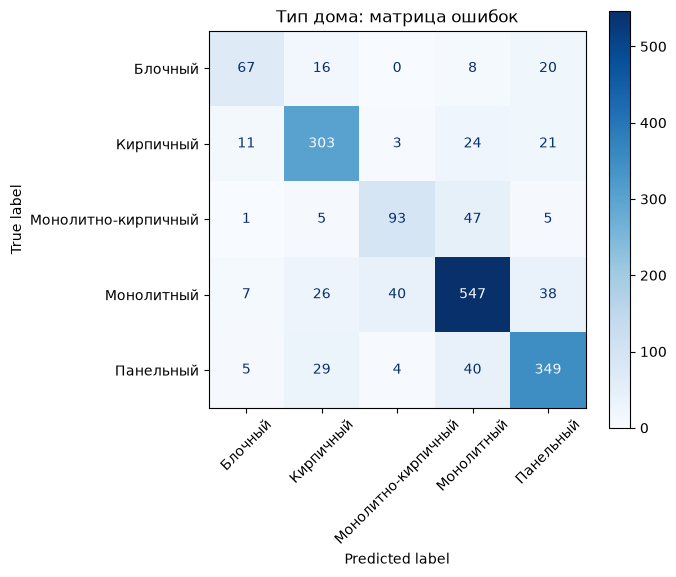

In [ ]:
# confusion matrix лучшей модели

best = search.best_estimator_
pred = best.predict(X_te)
print(classification_report(y_te, pred, target_names=le.classes_))

cm = confusion_matrix(y_te, pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, xticks_rotation=45, cmap='Blues')
ax.set_title('Тип дома: матрица ошибок')
plt.tight_layout()
plt.show()

## Анализ модели / признаков

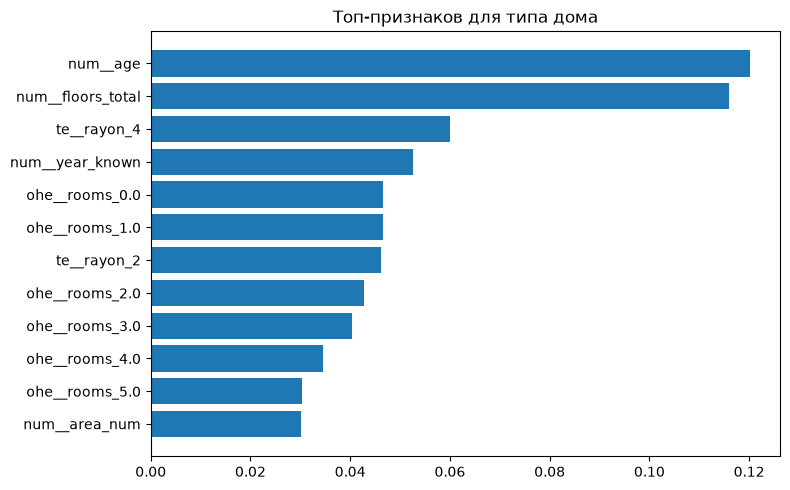

num__age             0.120
num__floors_total    0.116
te__rayon_4          0.060
num__year_known      0.053
ohe__rooms_0.0       0.047
ohe__rooms_1.0       0.047
te__rayon_2          0.046
ohe__rooms_2.0       0.043
ohe__rooms_3.0       0.040
ohe__rooms_4.0       0.035
ohe__rooms_5.0       0.030
num__area_num        0.030
dtype: float32

In [ ]:
names = best.named_steps['prep'].get_feature_names_out()
imp   = best.named_steps['model'].feature_importances_
top   = pd.Series(imp, index=names).sort_values(ascending=False).head(12)[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top.index, top.values)
plt.title('Топ-признаков для типа дома')
plt.tight_layout()
plt.show()
top[::-1].round(3)

In [ ]:
best.fit(X, y)   # на всех размеченных
Xu = unlab[feat].copy()
Xu['rooms'] = Xu['rooms'].astype(str)
proba  = best.predict_proba(Xu)
pred_u = le.inverse_transform(proba.argmax(1))

flats['house_type_filled'] = flats['house_type']
flats.loc[unlab.index, 'house_type_filled'] = pred_u
flats['house_type_known']  = flats['house_type'].notna().astype(int)
flats['ht_confidence'] = 1.0
flats.loc[unlab.index, 'ht_confidence'] = proba.max(1)

out = flats[['url', 'house_type_filled', 'house_type_known', 'ht_confidence']]
out.to_csv('flats_filled.csv', index=False, encoding='utf-8-sig')
print('flats_filled.csv редииии:', out.shape)
print('средняя уверенность по заполненным:', round(proba.max(1).mean(), 3))
out.head()

flats_filled.csv редииии: (11515, 4)
средняя уверенность по заполненным: 0.87


,url,house_type_filled,house_type_known,ht_confidence
0,https://www.cian.ru/sale/flat/323603252/,Монолитный,1,1.000000
1,https://www.cian.ru/sale/flat/322592319/,Кирпичный,0,0.845886
2,https://www.cian.ru/sale/flat/322116585/,Монолитный,1,1.000000
3,https://www.cian.ru/sale/flat/310065847/,Кирпичный,0,0.845459
4,https://www.cian.ru/sale/flat/321742080/,Монолитный,1,1.000000


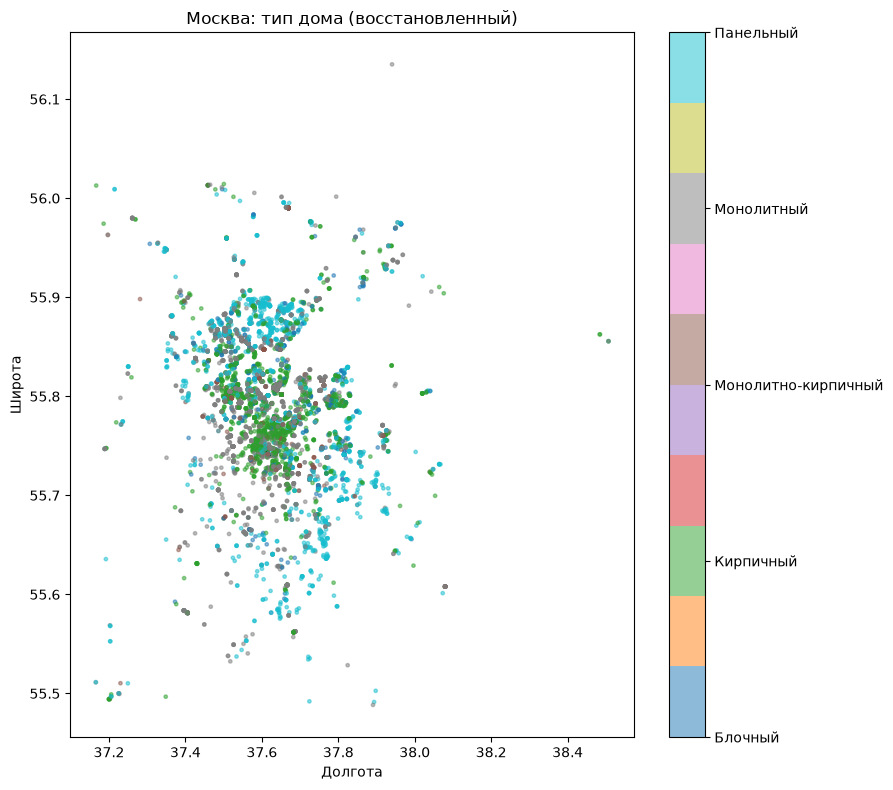

In [ ]:
codes = le.transform(flats['house_type_filled'])
plt.figure(figsize=(9, 8))
sc = plt.scatter(flats['lon'], flats['lat'], c=codes, cmap='tab10', s=6, alpha=0.5)
plt.title('Москва: тип дома (восстановленный)')
plt.xlabel('Долгота')
plt.ylabel('Широта')
cb = plt.colorbar(sc, ticks=range(len(le.classes_)))
cb.ax.set_yticklabels(le.classes_)
plt.tight_layout()
plt.show()

In [ ]:
flats['price_num'] = flats['price'].apply(to_num)
flats['ppm2_tys'] = flats['price_num'] / flats['area_num'] / 1000
flats = flats[flats['ppm2_tys'] <= 3000].copy()
flats['log_ppm2'] = np.log(flats['ppm2_tys'])
flats.shape

(11455, 33)

глянем на как себя велет восстановленный тип

тут три варианта что делать с пропусками:

выкинуть строки без типа (теряем кучу данных)

пометить их как анкновн

подставить то, что выдаст мл

In [ ]:
type_was_empty = flats['house_type'].isna()

drop_df = flats[~type_was_empty].copy()

unknown_df = flats.copy()
unknown_df['house_type'] = flats['house_type'].fillna('Unknown')

ml_df = flats.copy()
ml_df['house_type'] = flats['house_type_filled']

In [ ]:
num_features = ['area_num','rooms','floor_n','floors_total','floor_ratio','is_first','is_last',
                'metro_min','dist_center_km','age','year_known','sch_n','cli_n','kga_n','lat','lon']

def r2_of(df):
    X = df[num_features + ['house_type', 'rayon']]
    y = df['log_ppm2']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    prep = ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('ohe', OneHotEncoder(handle_unknown='ignore'), ['house_type']),
        ('te', TargetEncoder(), ['rayon']),
    ])
    model = Pipeline([('prep', prep),
                      ('model', XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                                             n_jobs=-1, random_state=42))])
    model.fit(X_train, y_train)
    return r2_score(y_test, model.predict(X_test))

In [ ]:
results = pd.DataFrame({
    'режим': ['drop', 'Unknown', 'ML'],
    'строк': [len(drop_df), len(unknown_df), len(ml_df)],
    'R2':    [round(r2_of(drop_df), 3), round(r2_of(unknown_df), 3), round(r2_of(ml_df), 3)],
})
results

,режим,строк,R2
0,drop,8504,0.816
1,Unknown,11455,0.821
2,ML,11455,0.824


короче дроп точно херня, потому что мы мало того, что выкинули данные, так еще и ниче не выиграли с этого


остальные же варианты тоже ничем не лучше, больше смахивает на везение/шум

а точно ли пропуски - новостройки, ща глянем

этажность: тип есть 14.0 , тип пуст 21.0
год неизвестен: тип есть 37 % , тип пуст 49 %


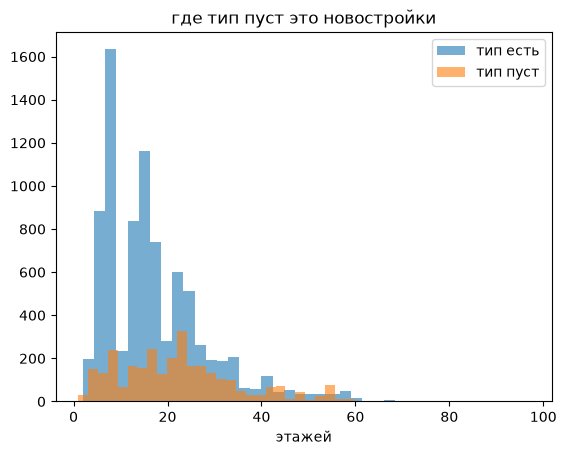

In [ ]:
print('этажность: тип есть', flats[~type_was_empty]['floors_total'].median(),
      ', тип пуст', flats[type_was_empty]['floors_total'].median())
print('год неизвестен: тип есть', round((flats[~type_was_empty]['year_known']==0).mean()*100), '%',
      ', тип пуст', round((flats[type_was_empty]['year_known']==0).mean()*100), '%')

plt.hist(flats[~type_was_empty]['floors_total'], bins=40, alpha=0.6, label='тип есть')
plt.hist(flats[type_was_empty]['floors_total'], bins=40, alpha=0.6, label='тип пуст')
plt.legend()
plt.xlabel('этажей')
plt.title('где тип пуст это новостройки')
plt.show()

ну да, это новостройки

в целом это целый сегмент рынка, поэтому норм было бы их заполнить мл

добавим уверенности и сделаем из нашего классификатора либо арсена маркаряна, либо задрипанного ботаника ссыкуна

In [ ]:
def r2_soft(df):
    feats = num_features + ['ht_confidence']
    X = df[feats + ['house_type', 'rayon']]
    y = df['log_ppm2']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    prep = ColumnTransformer([
        ('num', StandardScaler(), feats),
        ('ohe', OneHotEncoder(handle_unknown='ignore'), ['house_type']),
        ('te', TargetEncoder(), ['rayon']),
    ])
    model = Pipeline([('prep', prep),
                      ('model', XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                                             n_jobs=-1, random_state=42))])
    model.fit(X_train, y_train)
    return r2_score(y_test, model.predict(X_test))

print('без уверенности: ', round(r2_of(ml_df), 3))
print('с уверенностью: ', round(r2_soft(ml_df), 3))

без уверенности:  0.827
с уверенностью:  0.824


+- ноль разницы, а значит это лишнее

кандидатов под редевелопмент: 1285
rayon
Отрадное       60
Вешняки        52
Unknown        43
Бибирево       40
Дмитровский    37
Name: count, dtype: int64


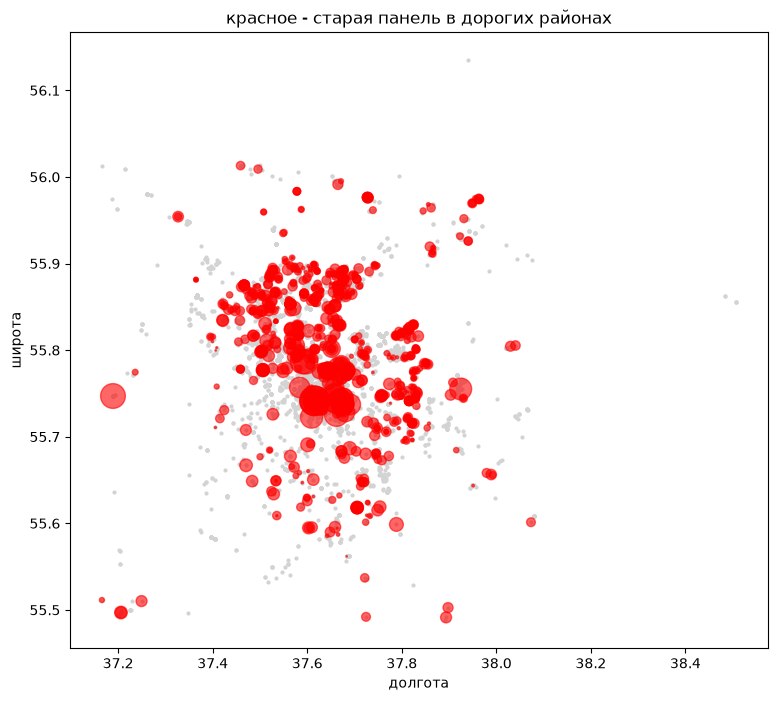

In [ ]:
mono_price = ml_df[ml_df['house_type'] == 'Монолитный'].groupby('rayon')['ppm2_tys'].median()
ml_df['mono_price'] = ml_df['rayon'].map(mono_price)

old_panel = ml_df[(ml_df['house_type'].isin(['Панельный', 'Блочный'])) & (ml_df['age'] >= 40)].copy()
old_panel['gap'] = old_panel['mono_price'] - old_panel['ppm2_tys']
old_panel = old_panel[old_panel['gap'] > 0]
print('кандидатов под редевелопмент:', len(old_panel))
print(old_panel['rayon'].value_counts().head())

plt.figure(figsize=(9, 8))
plt.scatter(ml_df['lon'], ml_df['lat'], s=4, c='lightgrey')
plt.scatter(old_panel['lon'], old_panel['lat'], s=old_panel['gap']/3, c='red', alpha=0.6)
plt.title('красное - старая панель в дорогих районах')
plt.xlabel('долгота')
plt.ylabel('широта')
plt.show()

было бы славно снести старые дома и построить на их месте более рентабельные, но тут че то в центре многовато старых (а их очев сносить нельзя)

по кордам определяем тип и цену

In [ ]:
nn = NearestNeighbors(n_neighbors=10).fit(flats[['lat', 'lon']].values)

clf_features = ['area_num','floor_n','floors_total','floor_ratio','is_first','is_last','metro_min',
                'dist_center_km','age','year_known','sch_n','cli_n','kga_n','lat','lon','rooms','rayon']

def predict_point(lat, lon, area=55, rooms=2):
    _, idx = nn.kneighbors([[lat, lon]])
    near = flats.iloc[idx[0]]
    floors = near['floors_total'].median()
    row = pd.DataFrame([{
        'area_num': area, 'rooms': float(rooms), 'floor_n': floors//2, 'floors_total': floors,
        'floor_ratio': 0.5, 'is_first': 0, 'is_last': 0,
        'metro_min': near['metro_min'].median(), 'dist_center_km': haversine(lat, lon),
        'age': near['age'].median(), 'year_known': 1,
        'sch_n': near['sch_n'].median(), 'cli_n': near['cli_n'].median(), 'kga_n': near['kga_n'].median(),
        'lat': lat, 'lon': lon, 'rayon': near['rayon'].mode()[0],
    }])
    row_clf = row.copy()
    row_clf['rooms'] = row_clf['rooms'].astype(str)
    house_type = le.inverse_transform(best.predict(row_clf[clf_features]))[0]
    row['house_type'] = house_type
    ppm2 = np.exp(best_rf.predict(row[num_features + ['house_type', 'rayon']]))[0]
    return house_type, round(ppm2)

In [ ]:
points = {'Хамовники (центр)': (55.736, 37.585),
          'Некрасовка (окраина)': (55.702, 37.92),
          'Бибирево (север)': (55.888, 37.60)}
for name, (lat, lon) in points.items():
    house_type, ppm2 = predict_point(lat, lon)
    print(name, house_type, ppm2, 'тыс/м2, квартира 55м2 ~', round(ppm2*55/1000), 'млн')

Хамовники (центр) Кирпичный 821 тыс/м2, квартира 55м2 ~ 45 млн
Некрасовка (окраина) Панельный 247 тыс/м2, квартира 55м2 ~ 14 млн
Бибирево (север) Панельный 298 тыс/м2, квартира 55м2 ~ 16 млн


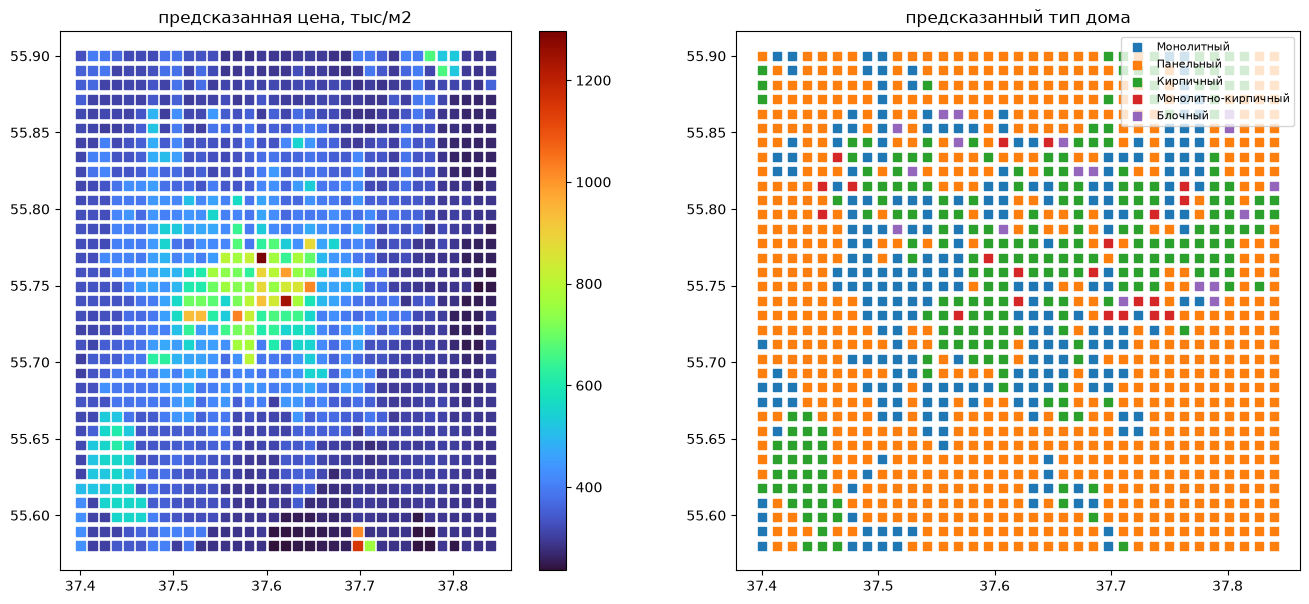

In [ ]:
lats = np.linspace(55.58, 55.90, 35)
lons = np.linspace(37.40, 37.84, 35)
grid = [(la, lo) for la in lats for lo in lons]
preds = [predict_point(la, lo) for la, lo in grid]

gdf = pd.DataFrame(grid, columns=['lat', 'lon'])
gdf['house_type'] = [p[0] for p in preds]
gdf['ppm2'] = [p[1] for p in preds]

fig, ax = plt.subplots(1, 2, figsize=(16, 7))
sc = ax[0].scatter(gdf['lon'], gdf['lat'], c=gdf['ppm2'], cmap='turbo', s=40, marker='s')
plt.colorbar(sc, ax=ax[0])
ax[0].set_title('предсказанная цена, тыс/м2')
for t in gdf['house_type'].unique():
    m = gdf['house_type'] == t
    ax[1].scatter(gdf[m]['lon'], gdf[m]['lat'], s=40, marker='s', label=t)
ax[1].legend(fontsize=8)
ax[1].set_title('предсказанный тип дома')
plt.show()

выводик

точность регрессии от восстановленного типа почти не вырославыводик


зато

мы получили карты для поиска перспективных районов + удивительный инструмент для того, чтобы только при помощи координат мы выводили тип дома и его ожидаемую цену :)

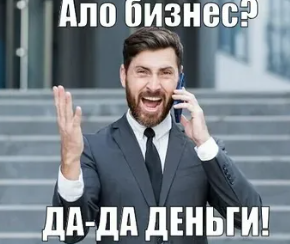